# Prac 03. Part 1

For this homework you are going to implement the **unsharp masking** filter (USM). It is a technique to improve the sharpness of an image by combining the image with its blurred (unsharp) version. See the Wikipedia [page](https://en.wikipedia.org/wiki/Unsharp_masking) for more details.

### Unsharp Masking (USP)
The USM technique consists of the following steps:
* Load the image you will be working with.
* Create a blurred (unsharp) version of the original image.
* Add the unsharp image (with a certain **weight**) to the original.

To sum it up, the USM performs the following operation:

`sharpened = original + (original − unsharp) × amount`

Even though we provide you an image to work with, you are welcome to use your own images :-)

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

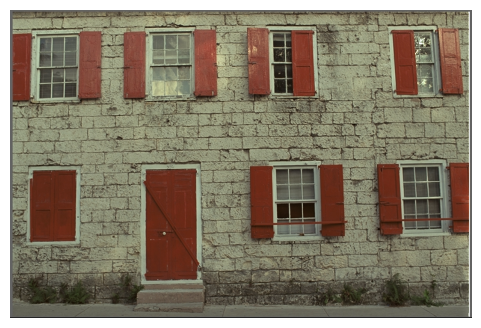

In [4]:
img = cv2.imread('data/kodim01.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 4))
plt.imshow(img)
plt.axis('off')
plt.show()

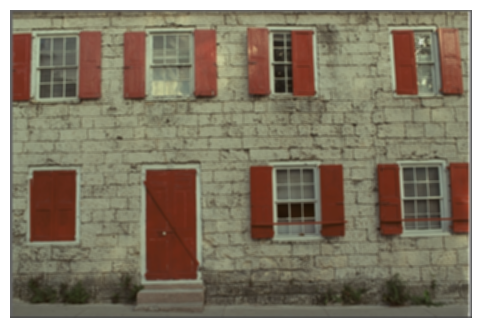

In [5]:
# Create a blurred (unsharp) version of the original image (you can use Gaussian blurring)
unsharp = cv2.GaussianBlur(img, ksize=(5, 5), sigmaX=5)

plt.figure(figsize=(6, 4))
plt.imshow(unsharp)
plt.axis('off')
plt.show()

In [8]:
# Create the difference image (original − unsharp)
# Note: Remember that you are working with uint8 data types. Any addition or substractions
# might result in overflow or underflow, respectively. You can prevent this by casting the images to float.
diff = img.astype(np.float32) - unsharp.astype(np.float32)

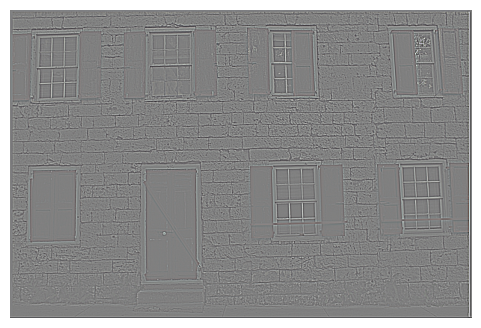

In [9]:
plt.figure(figsize=(6, 4))
plt.imshow(np.clip(diff + 128, 0, 255).astype(np.uint8))
plt.axis('off')
plt.show()

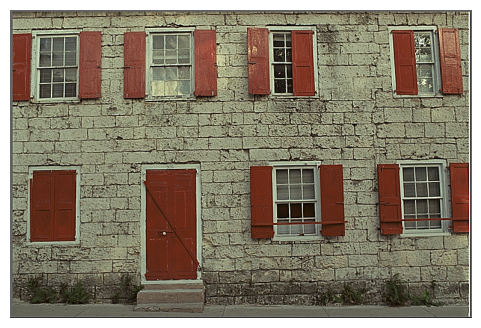

In [12]:
# Apply USM to get the resulting image using `sharpened = original + (original − unsharp) × amount`
# Note: Again, take care of underflows/overflows if necessary.

amount = 1.0

sharpened = img.astype(np.float32) + diff * amount

sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

plt.figure(figsize=(6, 4))
plt.imshow(sharpened)
plt.axis('off')
plt.show()

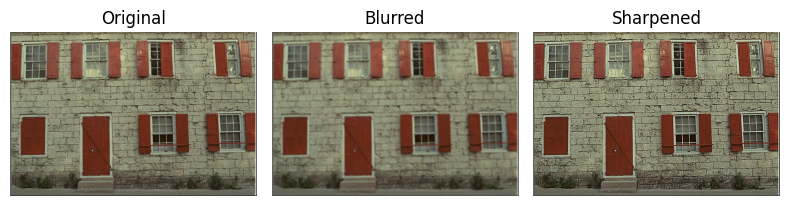

In [11]:
plt.figure(figsize=(8, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(unsharp)
plt.title('Blurred')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sharpened)
plt.title('Sharpened')
plt.axis('off')

plt.tight_layout()
plt.show()

### Questions
* What is a good (reasonable) value for the `amount` parameter?
 * What happens if it is too small?
 * What happens if it is too large?

### Answers

1. A reasonable value for `amount` is about 1.0. It provides a visible sharpening effect without making the image look too artificial.

2. If `amount` is too small, the difference between the original and sharpened image will be hardly noticeable.

3. If `amount` is too large, the image becomes oversharpened. Strong halos and unnatural edges may appear, and image noise may also become more visible.